# Chapter 4: IMDB Binary Classification

## Section 1: Define and compare the learning problem

The MNIST model classified handwritten-digit images into ten classes.

The IMDB model classifies movie reviews into two classes:

$$
y_i \in \{0,1\}
$$

where:

- $y_i=0$ means a negative review.
- $y_i=1$ means a positive review.

This is a single-label binary-classification problem.

The general model notation remains:

$$
\hat{y}_i=f_\theta(x_i)
$$

However, the input representation, architecture, output activation, and
loss function will differ from MNIST.

### Initial comparison

| Design decision | MNIST | IMDB |
|---|---|---|
| Input modality | Image | Text |
| Learning task | Multiclass classification | Binary classification |
| Number of classes | 10 | 2 |
| Target values | 0 through 9 | 0 or 1 |
| Processed input size | 784 | 10,000 |
| Hidden architecture | 512 | 16 then 16 |
| Output neurons | 10 | 1 |
| Output activation | Softmax | Sigmoid |
| Loss | Sparse categorical cross-entropy | Binary cross-entropy |
| Prediction | Largest probability position | Probability threshold |

## Section 2: Load and inspect the IMDB dataset

Conceptually, the raw observation is a written movie review:

$$
s_i=\text{review text}
$$

Text cannot be supplied directly to a Dense layer. It must be converted
into numbers:

$$
r_i=T(s_i)
$$

where $T$ is a tokenization and integer-encoding process.

The Keras IMDB dataset has already performed this first preprocessing
step. Each review is supplied as a sequence of integer word identifiers:

$$
r_i=[t_1,t_2,\ldots,t_{L_i}]
$$

The length $L_i$ may differ among reviews.

This distinction is important: the Keras dataset does not initially give us ordinary English strings. It gives us reviews that have already been converted into integer token sequences.

In [5]:
from tensorflow.keras.datasets import imdb

vocabulary_size = 10_000

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=vocabulary_size
)

In [18]:
print("Number of training reviews:", len(train_data))
print("Number of training labels:", len(train_labels))
print("Number of test reviews:", len(test_data))
print("Number of test labels:", len(test_labels))

print()
print("First training label:", train_labels[0])
print("First review length:", len(train_data[0]))
print("First 20 token IDs:")
print(train_data[0][:20])

Number of training reviews: 25000
Number of training labels: 25000
Number of test reviews: 25000
Number of test labels: 25000

First training label: 1
First review length: 218
First 20 token IDs:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]


### Examine the variable lengths

In [30]:
review_lengths = [len(review) for review in train_data]

print("Shortest review:", min(review_lengths))
print("Longest review:", max(review_lengths))
print("Average review length:", sum(review_lengths) / len(review_lengths))

print()
print("First five review lengths:", review_lengths[:5])

Shortest review: 11
Longest review: 2494
Average review length: 238.71364

First five review lengths: [218, 189, 141, 550, 147]


This reveals our first major difference from MNIST:

$$ \text{MNIST input shape}=28\times28 $$

is fixed, while:

$$ \text{IMDB review length}=L_i $$

varies among observations.

#### Decode the first review

In [41]:
word_index = imdb.get_word_index()

reverse_word_index = {
    index: word
    for word, index in word_index.items()
}

decoded_review = " ".join(
    reverse_word_index.get(token_id - 3, "?")
    for token_id in train_data[0]
)

print("Label:", train_labels[0])
print()
print(decoded_review)

Label: 1

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don

The subtraction by 3 accounts for special reserved token identifiers used by the dataset.

The important representation chain is now:

$$ s_i \xrightarrow{T} r_i $$

where:

\(s_i\) is the original review text.
\(T\) tokenizes and maps words to integer identifiers.
\(r_i\) is a variable-length integer sequence.

This is only the first preprocessing stage. A Dense network requires every observation to have the same numerical shape. Our next step will therefore be:

$$ r_i \xrightarrow{P} x_i\in\{0,1\}^{10000} $$

We will turn each review into a 10,000-element vector describing which vocabulary words are present. That is the direct IMDB counterpart to flattening and scaling the MNIST images.

## Why did they choose 10,000 words?

10,000 is the chosen vocabulary size. Each position in the input vector represents one token ID. It is a preprocessing choice, not a number calculated from the length of a review.

Remember our small vocabulary example:

Position	Word
0	good
1	bad
2	fun
3	boring

For “good, fun,” the vector is:

$$ x_i=[1,0,1,0] $$

Four vocabulary entries require four positions. Every review gets the same four positions, regardless of its length.

Chollet’s IMDB example applies that same idea at a larger scale:

$$ \text{10,000 token positions} \quad\Rightarrow\quad x_i\in\{0,1\}^{10000} $$

A position contains:

1 if that token occurs in the review.
0 if it does not.

Repeated occurrences still produce a 1. This representation records presence; it discards word order and repetition counts.

The choice appears here:

vocabulary_size = 10_000

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=vocabulary_size
)

This limits the retained vocabulary to frequent words, with some IDs reserved for special tokens. It does not make each loaded review 10,000 tokens long. Our next vectorization step creates the fixed-length vector.

Why choose 10,000? It is a practical compromise:

Smaller vocabulary	Larger vocabulary
Less memory and computation	Includes more uncommon words
Fewer first-layer weights	More first-layer weights
May omit useful words	May include rare, less useful words

We could experiment with 5,000 or 20,000 and compare validation performance. Ten thousand is not a mathematically optimal or mandatory value.

The direct comparison with MNIST is:

$$ \underbrace{784}_{\text{pixel positions}} \qquad\text{versus}\qquad \underbrace{10{,}000}_{\text{token positions}} $$

For your handwritten notes: “The input width comes from the representation we choose. For this IMDB model, we choose a vocabulary of 10,000 token positions, so each review becomes a 10,000-feature vector.”

## Section 3: Vectorize the reviews
Now let’s turn each review’s token sequence into the 10,000-feature vector we just discussed. This is called multi-hot encoding, because several positions can contain 1.

Each review is currently a variable-length sequence of token IDs:

$$
r_i=[t_1,t_2,\ldots,t_{L_i}]
$$

Preprocessing creates a fixed-length vector:

$$
x_i=P(r_i)\in\{0,1\}^{10000}
$$

For token position $j$:

$$
x_{i,j}=
\begin{cases}
1 & \text{if token }j\text{ occurs in review }i\\
0 & \text{otherwise}
\end{cases}
$$

This representation preserves token presence, but discards token order
and repetition counts.

### First, try a tiny example. Imagine eight possible token IDs, numbered 0 through 7:

In [51]:
import numpy as np

example_review = [1, 3, 3, 6]

example_vector = np.zeros(8, dtype="float32")
example_vector[example_review] = 1.0

print(example_vector)

[0. 1. 0. 1. 0. 0. 1. 0.]


Token 3 appears twice, but position 3 still contains just 1:

$$ [1,3,3,6]\xrightarrow{P}[0,1,0,1,0,0,1,0] $$

Now apply the same operation to a collection of reviews.

In [60]:
def vectorize_sequences(sequences, dimension=10_000):
    results = np.zeros(
        (len(sequences), dimension),
        dtype="float32"
    )

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

Each part has a direct meaning:

Code	Meaning
len(sequences)	Number of reviews
dimension	Number of available token positions
np.zeros(...)	Begin with every token marked absent
results[i, sequence] = 1.0	Mark the tokens present in review \(i\)

Run it on the data loaded in Section 2:

In [68]:
x_train = vectorize_sequences(train_data, vocabulary_size)
x_test = vectorize_sequences(test_data, vocabulary_size)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)
print("Data type:", x_train.dtype)

Training shape: (25000, 10000)
Test shape: (25000, 10000)
Data type: float32


These two dense arrays together use approximately 2 GB of memory with float32.

Inspect one review before and after vectorization:

In [75]:
print("Original token count:", len(train_data[0]))
print("Distinct token count:", len(set(train_data[0])))
print("Vector shape:", x_train[0].shape)
print("Number of positions containing 1:", int(x_train[0].sum()))

Original token count: 218
Distinct token count: 120
Vector shape: (10000,)
Number of positions containing 1: 120


The distinct token count should match the number of positions containing 1. The vector length remains 10,000 regardless of either count.

Finally, prepare the labels:

In [81]:
y_train = np.asarray(train_labels, dtype="float32")
y_test = np.asarray(test_labels, dtype="float32")

print("Training label shape:", y_train.shape)
print("First five labels:", y_train[:5])

Training label shape: (25000,)
First five labels: [1. 0. 0. 1. 0.]


Converting their data type leaves their meanings unchanged: 0 = negative, 1 = positive.

Your model inputs now have a clear contract:

Tensor	Shape	Meaning
x_train	(25000, 10000)	One row of token-presence features per review
y_train	(25000,)	One sentiment label per review

For your handwritten notes:

$$ \boxed{ \text{variable-length token sequence} \xrightarrow{P} \text{fixed-length presence vector} } $$

Next, we’ll build the $(10{,}000\rightarrow16\rightarrow16\rightarrow1$) network and connect its layers to your $(Wx+b$) equations.

## Section 4: Build the IMDB network
--------
- Now we’ll build the IMDB network: \(10{,}000\rightarrow16\rightarrow16\rightarrow1\) and connect each layer to your handwritten equations.

Your preprocessing provides 10,000 token-presence features per review. The network combines those features into 16 activations, transforms them into another 16, and produces one estimated probability of positive sentiment.
--------
The architecture is:

$$
10{,}000 \longrightarrow 16 \longrightarrow 16 \longrightarrow 1
$$

- 10,000 input features represent token presence.
- Two hidden Dense layers each contain 16 neurons and use ReLU.
- One output neuron uses sigmoid to estimate positive sentiment.

The hidden-layer widths are design choices. The single output is
appropriate because the target has two possible values: 0 and 1.

In [86]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(10_000,)),
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dense(16, activation="relu", name="hidden_2"),
    layers.Dense(1, activation="sigmoid", name="sentiment")
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### Forward pass for one review
Each Dense layer has one weight per input-to-neuron connection and one bias per neuron. For the first layer:

$$ 10{,}000\times16+16=160{,}016 $$

Now connect the code to the mathematics. Use one review as a column vector, just as in your handwritten notes:

x
i
	​

∈R
10000×1

We use column vectors in these equations.

The first hidden layer calculates:

$$
a_i^{(1)}
=
\operatorname{ReLU}\left(W^{(1)}x_i+b^{(1)}\right)
$$

The second hidden layer calculates:

$$
a_i^{(2)}
=
\operatorname{ReLU}\left(W^{(2)}a_i^{(1)}+b^{(2)}\right)
$$

The output layer calculates:

$$
z_i^{(3)}=W^{(3)}a_i^{(2)}+b^{(3)}
$$

$$
\hat{y}_i=\sigma\left(z_i^{(3)}\right)
$$

Here, sigmoid is:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The scalar output estimates the probability that the review is positive.

The shape relationships are:

Layer	Weight shape in our equations	Bias shape	Output shape
First hidden	\((16,10000)\)	\((16,1)\)	\((16,1)\)
Second hidden	\((16,16)\)	\((16,1)\)	\((16,1)\)
Output	\((1,16)\)	\((1,1)\)	\((1,1)\)

For example, the first multiplication is:

$$ (16,10000)(10000,1)=(16,1) $$

Why does binary classification need only one output? If the model estimates:

$$ P(\text{positive}\mid x_i)=0.8 $$

then the other probability follows:

$$ P(\text{negative}\mid x_i)=1-0.8=0.2 $$

MNIST needed ten softmax outputs for its ten classes. Here, one sigmoid output supplies enough information for both classes.

In [90]:
for layer in model.layers:
    kernel, bias = layer.get_weights()
    print(
        f"{layer.name}: "
        f"kernel={kernel.shape}, bias={bias.shape}"
    )

hidden_1: kernel=(10000, 16), bias=(16,)
hidden_2: kernel=(16, 16), bias=(16,)
sentiment: kernel=(16, 1), bias=(1,)


As with MNIST, Keras stores its kernels for row-based batches, so each kernel is the transpose of the corresponding mathematical weight matrix.

For your handwritten notes, capture this single forward-pass expression:

$$ \boxed{ f_\theta(x_i)= \sigma\left( W^{(3)} \operatorname{ReLU}\left( W^{(2)} \operatorname{ReLU}(W^{(1)}x_i+b^{(1)}) +b^{(2)} \right) +b^{(3)} \right) } $$

The network is now constructed, with initialized parameters. Next, we’ll connect its sigmoid output to binary cross-entropy loss, then reserve validation data before training.

## Section 5: Compile the model 
### - Next we’ll compile the IMDB model and reserve a validation set. The validation set will help us choose how long to train while keeping the test set for final evaluation.

The model outputs an estimated probability of positive sentiment:

$$
\hat{y}_i=f_\theta(x_i)
$$

The correct label is:

$$
y_i\in\{0,1\}
$$

Binary cross-entropy measures the prediction error:

$$
L_i=-\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

For a positive review, $y_i=1$, so:

$$
L_i=-\log(\hat{y}_i)
$$

For a negative review, $y_i=0$, so:

$$
L_i=-\log(1-\hat{y}_i)
$$

The loss is small when the model assigns a high probability to the
correct class.

The two cases make the equation easier to understand:

Actual sentiment	Model output \(\hat y_i\)	Probability assigned to correct class	Loss
Positive	0.9	0.9	\(-\log(0.9)\approx0.105\)
Negative	0.1	0.9	\(-\log(0.9)\approx0.105\)
Negative	0.9	0.1	\(-\log(0.1)\approx2.303\)

The output always means estimated probability of positive sentiment. The label determines which probability the loss evaluates.

In [91]:
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Compared with MNIST, the optimizer stays the same; the loss changes to match the output and target:

Model	Output	Target	Loss
MNIST	Ten softmax probabilities	Integer 0–9	Sparse categorical cross-entropy
IMDB	One sigmoid probability	0 or 1	Binary cross-entropy

## Section 6: Create a validation set
### - Now reserve validation data. Following the book’s example, we’ll take 10,000 reviews from the supplied training set for validation, leaving 15,000 for parameter updates.

We divide the original 25,000 training reviews into:

- 15,000 reviews for learning weights and biases.
- 10,000 reviews for monitoring validation performance.

The separate 25,000 test reviews remain reserved for final evaluation.

Validation computes loss and accuracy without updating model parameters.
We use validation results to guide choices such as the number of epochs.

In [93]:
x_val = x_train[:10_000]
y_val = y_train[:10_000]

partial_x_train = x_train[10_000:]
partial_y_train = y_train[10_000:]

print("Training inputs:", partial_x_train.shape)
print("Training labels:", partial_y_train.shape)
print("Validation inputs:", x_val.shape)
print("Validation labels:", y_val.shape)

Training inputs: (15000, 10000)
Training labels: (15000,)
Validation inputs: (10000, 10000)
Validation labels: (10000,)


The matching slices preserve alignment: each review still has its own correct label.

For your handwritten notes:

Dataset	Updates weights?	Purpose
Training	Yes	Learn parameters
Validation	No	Guide model and training choices
Test	No	Assess the final chosen model

Next, we’ll train while recording both training and validation loss, so we can see when additional training starts fitting the training data better without improving generalization.

## Section 7: Train with validation

During each epoch, the model learns from the 15,000 training reviews.

For each training batch, it calculates:

$$
\hat{y}_i=f_\theta(x_i)
$$

then computes binary cross-entropy loss and uses its gradients
to update the weights and biases.

At the end of the epoch, the model evaluates the 10,000 validation
reviews using the current parameters.

Validation does not update those parameters.

We record four measurements:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy

In [94]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.7120 - loss: 0.5899 - val_accuracy: 0.8695 - val_loss: 0.3894
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8954 - loss: 0.3384 - val_accuracy: 0.8745 - val_loss: 0.3253
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9199 - loss: 0.2476 - val_accuracy: 0.8855 - val_loss: 0.2910
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9394 - loss: 0.1914 - val_accuracy: 0.8897 - val_loss: 0.2755
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9509 - loss: 0.1622 - val_accuracy: 0.8856 - val_loss: 0.2861
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9587 - loss: 0.1336 - val_accuracy: 0.8852 - val_loss: 0.2847
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9671 - loss: 0.1141 - val_accuracy: 0.8666 - val_loss: 0.3485
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9739 - loss: 0.0971 - val_accuracy: 0.8715 - val_lo

This uses the model you already constructed and compiled. Running this cell again continues training from its current weights.

Each epoch has:

$$ \left\lceil\frac{15{,}000}{512}\right\rceil=30 $$

training batches, with a smaller final batch. After those parameter updates, Keras evaluates the validation set.

You should see output containing:

Epoch 1/20
... accuracy: ... loss: ... val_accuracy: ... val_loss: ...

We are running 20 epochs to observe how performance changes. Twenty is an experimental duration, not a claim that 20 epochs is best.

Once training finishes, add this Code cell to inspect the recorded values:

In [95]:
print(history.history.keys())

for epoch, (train_loss, val_loss) in enumerate(
    zip(history.history["loss"], history.history["val_loss"]),
    start=1
):
    print(
        f"Epoch {epoch:2d}: "
        f"training loss = {train_loss:.4f}, "
        f"validation loss = {val_loss:.4f}"
    )

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Epoch  1: training loss = 0.5177, validation loss = 0.3894
Epoch  2: training loss = 0.3138, validation loss = 0.3253
Epoch  3: training loss = 0.2396, validation loss = 0.2910
Epoch  4: training loss = 0.1927, validation loss = 0.2755
Epoch  5: training loss = 0.1595, validation loss = 0.2861
Epoch  6: training loss = 0.1362, validation loss = 0.2847
Epoch  7: training loss = 0.1160, validation loss = 0.3485
Epoch  8: training loss = 0.0981, validation loss = 0.3403
Epoch  9: training loss = 0.0846, validation loss = 0.3513
Epoch 10: training loss = 0.0728, validation loss = 0.3600
Epoch 11: training loss = 0.0631, validation loss = 0.3655
Epoch 12: training loss = 0.0542, validation loss = 0.3914
Epoch 13: training loss = 0.0435, validation loss = 0.4225
Epoch 14: training loss = 0.0370, validation loss = 0.4288
Epoch 15: training loss = 0.0328, validation loss = 0.4517
Epoch 16: training loss = 0.0252, validation loss = 0.4

Look for a pattern where training loss continues falling but validation loss starts rising. That suggests additional training is fitting the training examples more closely while predictions on held-out reviews are getting worse.

For your handwritten notes:

$$ \boxed{ \text{Lower training loss alone does not imply better generalization.} } $$

Next, we’ll plot the two loss curves and identify the epoch with the lowest validation loss. Keep the test set untouched while we make that choice.

## Section 8: Inspect learning curves

Training loss measures performance on the reviews used to update
the model's parameters.

Validation loss measures performance on held-out reviews.

For epoch $e$, let the validation loss be:

$$
L_{\mathrm{val}}^{(e)}
$$

We select the epoch with the lowest observed validation loss:

$$
e^*=\operatorname*{argmin}_{e}L_{\mathrm{val}}^{(e)}
$$

If training loss continues falling while validation loss rises
over several epochs, that is evidence of overfitting.

### Plot both loss curves with this Code cell. The dark background keeps the plot consistent with your screen preference:

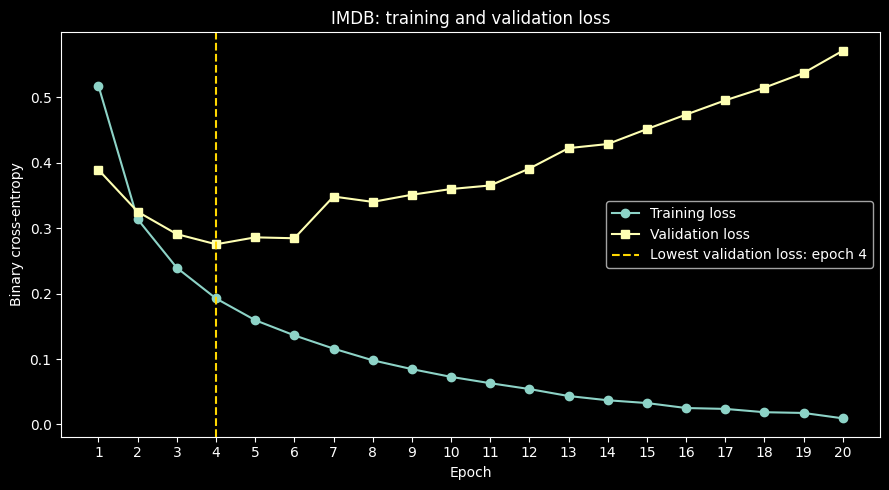

Selected epoch: 4
Lowest validation loss: 0.2755


In [96]:
import numpy as np
import matplotlib.pyplot as plt

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs = np.arange(1, len(training_loss) + 1)
best_epoch = int(np.argmin(validation_loss)) + 1

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(epochs, training_loss, "o-", label="Training loss")
    ax.plot(epochs, validation_loss, "s-", label="Validation loss")

    ax.axvline(
        best_epoch,
        color="gold",
        linestyle="--",
        label=f"Lowest validation loss: epoch {best_epoch}"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary cross-entropy")
    ax.set_title("IMDB: training and validation loss")
    ax.set_xticks(epochs)
    ax.legend()

    plt.tight_layout()
    plt.show()

print("Selected epoch:", best_epoch)
print(f"Lowest validation loss: {validation_loss[best_epoch - 1]:.4f}")

np.argmin() returns the position of the smallest value. We add 1 because Python positions begin at 0, while our epoch labels begin at 1.

Read your plot using these patterns:

Pattern	Interpretation
Both losses decrease	Learning is improving training and validation performance
Training loss decreases; validation loss rises persistently	Evidence of overfitting
Validation loss fluctuates slightly	Some variation is normal; inspect the broader trend

We haven’t seen your results yet, so let your actual curve determine the selected epoch.

Also inspect accuracy, using another Code cell:

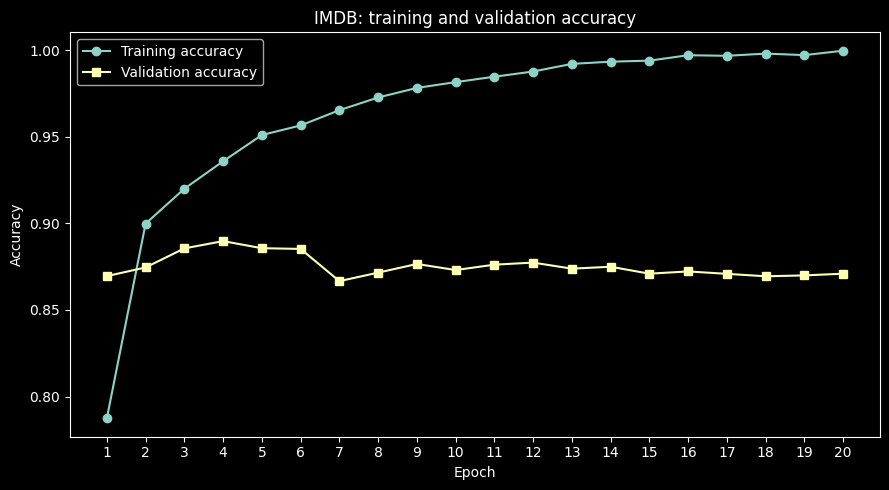

In [97]:
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        epochs, history.history["accuracy"],
        "o-", label="Training accuracy"
    )
    ax.plot(
        epochs, history.history["val_accuracy"],
        "s-", label="Validation accuracy"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("IMDB: training and validation accuracy")
    ax.set_xticks(epochs)
    ax.legend()

    plt.tight_layout()
    plt.show()

Accuracy and loss may tell slightly different stories. A prediction changing from 0.6 to 0.9 for a positive review remains a correct classification, but its loss improves. Loss accounts for the probability assigned to the correct label, while accuracy counts correct classifications.

Selecting best_epoch does not restore that epoch’s weights. Your current model still has the parameters from the final training epoch; history stores measurements, not copies of those parameters.

For your handwritten notes:

$$ \boxed{\text{Use validation performance to choose training duration.}} $$

Next, we’ll create a fresh model, train it on all 25,000 training reviews for the selected number of epochs, and then evaluate it on the untouched test set.

## Section 9: Train the final model and evaluate it
### Now we’ll train a fresh IMDB model for best_epoch epochs, then evaluate it on the test set.

We use a fresh model because the previous one has already trained for 20 epochs. Calling fit() again would continue from those weights.
Validation results determined our chosen training duration:

$$
e^*=\operatorname*{argmin}_{e}L_{\mathrm{val}}^{(e)}
$$

We now initialize a fresh model and train it for $e^*$ epochs using
all 25,000 reviews in the original training set.

The former validation reviews can now participate in training because
we have fixed the training duration.

The separate test set remains reserved for final evaluation.

In [98]:
from tensorflow import keras
from tensorflow.keras import layers

final_model = keras.Sequential([
    keras.Input(shape=(10_000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Selected number of epochs:", best_epoch)

Selected number of epochs: 4


This creates new weights and a new optimizer. The variable model still refers to your earlier experimental model; final_model refers to this fresh one.

Train using the complete training set:

In [99]:
final_history = final_model.fit(
    x_train,
    y_train,
    epochs=best_epoch,
    batch_size=512
)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7098 - loss: 0.5690
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8980 - loss: 0.2928
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9246 - loss: 0.2166
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9377 - loss: 0.1734


Notice the inputs:

Earlier experiment	Final training
partial_x_train: 15,000 reviews	x_train: 25,000 reviews
Validation measured after each epoch	Training duration already selected

The selected epoch count is a practical estimate. A fresh initialization and larger training set mean the learning trajectory will differ from the earlier experiment.

Evaluate the trained model:

In [100]:
test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    batch_size=512,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.2851
Test accuracy: 88.68%


### What final evaluation means

For each test review, the trained model estimates positive sentiment:

$$
\hat{y}_i=f_{\theta_{\mathrm{final}}}(x_i)
$$

Using a threshold of 0.5, we classify the review as positive when
the estimated probability exceeds 0.5.

Evaluation measures performance without updating the parameters.

We use the test result to report final performance. Further model
choices should be guided by validation data rather than repeated
attempts to improve this test score.

For your handwritten notes:

$$ \boxed{ \text{Validation selects the training duration;} \quad \text{testing assesses the resulting model.} } $$

Next, we’ll inspect individual review predictions and connect the sigmoid probability to the review’s actual sentiment.

## Section 10: Predict sentiment for one review

The model receives a vector of token-presence features:

$$
x_i=P(r_i)
$$

Its sigmoid output estimates the probability of positive sentiment:

$$
\hat{y}_i=f_{\theta_{\mathrm{final}}}(x_i)
$$

We convert that probability into a class:

$$
\hat{c}_i=
\begin{cases}
1 & \text{if }\hat{y}_i>0.5\\
0 & \text{otherwise}
\end{cases}
$$

Here, 1 means positive and 0 means negative.

### Select a review and predict.

In [101]:
sample_index = 0

sample_batch = x_test[sample_index : sample_index + 1]
prediction = final_model.predict(sample_batch, verbose=0)

positive_probability = float(prediction[0, 0])
predicted_class = int(positive_probability > 0.5)
actual_class = int(y_test[sample_index])

sentiment_names = {0: "Negative", 1: "Positive"}

print("Input shape:", sample_batch.shape)
print("Output shape:", prediction.shape)
print()
print(f"Estimated positive probability: {positive_probability:.4f}")
print("Predicted sentiment:", sentiment_names[predicted_class])
print("Actual sentiment:   ", sentiment_names[actual_class])
print("Correct prediction: ", predicted_class == actual_class)

Input shape: (1, 10000)
Output shape: (1, 1)

Estimated positive probability: 0.1979
Predicted sentiment: Negative
Actual sentiment:    Negative
Correct prediction:  True


The slice preserves the batch dimension. prediction[0, 0] selects the first review’s single output.

Compare this with MNIST:

Model	Output for one observation	Class decision
MNIST	Ten probabilities	Select the largest with argmax
IMDB	One positive-sentiment probability	Compare with 0.5

### Display the review's words in another Code Cell

In [102]:
from tensorflow.keras.datasets import imdb

word_index = imdb.get_word_index()

# Loaded review token IDs are offset by 3.
id_to_word = {
    index + 3: word
    for word, index in word_index.items()
}

id_to_word.update({
    0: "<PAD>",
    1: "<START>",
    2: "<UNKNOWN>"
})

decoded_review = " ".join(
    id_to_word.get(token_id, "<UNKNOWN>")
    for token_id in test_data[sample_index]
)

print(decoded_review)

<START> please give this one a miss br br <UNKNOWN> <UNKNOWN> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNKNOWN> so all you madison fans give this a miss


This reconstructs readable words from the stored sequence. It cannot recover words replaced by <UNKNOWN> or the exact original formatting.

Notice the two representations you are using:

test_data[sample_index] retains token order, so we can display the review.
x_test[sample_index] records only token presence; this is what the model actually receives.

For example, an output of \(0.92\) means the model assigns positive sentiment an estimated probability of 92%. It does not mean the review is “92% positive,” nor guarantee that 92% of similarly scored predictions are correct.

For your handwritten notes:

$$ \boxed{ \text{Review tokens} \xrightarrow{P} \text{presence vector} \xrightarrow{f_\theta} \text{positive probability} \xrightarrow{\text{threshold}} \text{sentiment class} } $$

Change sample_index to inspect another review, then rerun both cells. Next, we’ll examine incorrect predictions to understand the limitations of this representation.

## Section 11: Inspect prediction errors
### Now we’ll inspect incorrect IMDB predictions and consider what the model’s token-presence representation leaves out.
For each test review, we predict a sentiment class:

$$
\hat{c}_i=
\begin{cases}
1 & \text{if }f_\theta(x_i)>0.5\\
0 & \text{otherwise}
\end{cases}
$$

A classification error occurs when:

$$
\hat{c}_i \neq y_i
$$

We examine errors to understand the model's limitations.
Any subsequent model tuning should use validation data.

### Predict all test reviews in a Code cell:

In [103]:
import numpy as np

test_probabilities = final_model.predict(
    x_test,
    batch_size=512,
    verbose=0
).reshape(-1)

test_predictions = (test_probabilities > 0.5).astype("int32")

incorrect_indices = np.flatnonzero(test_predictions != y_test)

print("Reviews evaluated:", len(y_test))
print("Incorrect predictions:", len(incorrect_indices))
print(f"Accuracy: {np.mean(test_predictions == y_test):.2%}")

Reviews evaluated: 25000
Incorrect predictions: 2831
Accuracy: 88.68%


.reshape(-1) changes the output from (25000, 1) into (25000,). This makes its shape match y_test for an element-by-element comparison.

Read three mistakes. This cell uses id_to_word and sentiment_names from Section 10:

In [104]:
for index in incorrect_indices[:3]:
    actual = int(y_test[index])
    predicted = int(test_predictions[index])
    probability = float(test_probabilities[index])

    review_text = " ".join(
        id_to_word.get(token_id, "<UNKNOWN>")
        for token_id in test_data[index]
    )

    print(f"\nReview index: {index}")
    print("Actual sentiment:", sentiment_names[actual])
    print("Predicted sentiment:", sentiment_names[predicted])
    print(f"Estimated positive probability: {probability:.4f}")
    print("Review excerpt:")
    print(review_text[:1_200])
    print("-" * 70)


Review index: 3
Actual sentiment: Negative
Predicted sentiment: Positive
Estimated positive probability: 0.7824
Review excerpt:
<START> i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it this was absolutely idiotic the things that happen with the dead kids are very cool but the alive people are absolute idiots i am a grown man pretty big and i can defend myself well however i would not do half the stuff the little girl does in this movie also the mother in this movie is reckless with her children to the point of neglect i wish i wasn't so angry about her and her actions because i would have otherwise enjoyed the flick what a number she was take my advise and fast forward through everything you see her do until the end also is anyone else getting sick of watching movies that are filmed so dark anymore one can hardly see what is being filmed as an audience we are <UNKNOWN> involved with the 

These are excerpts; the full review may contain context missing from the displayed portion. Look for mixed opinions, negation, sarcasm, or unknown words. Those are possible explanations to investigate—not proof of why a particular prediction failed.

One limitation we can demonstrate exactly is loss of word order.

Consider these two sentences:

“The acting was good, the story was bad.”
“The acting was bad, the story was good.”

They contain the same words but attach the judgments to different things. Our multi-hot representation gives them identical vectors.

This small Code cell reproduces that problem using token IDs:

In [106]:
sequence_a = [[1, 3, 6]]
sequence_b = [[6, 3, 1, 3]]

vector_a = vectorize_sequences(sequence_a, dimension=8)
vector_b = vectorize_sequences(sequence_b, dimension=8)

print("Vector A:", vector_a[0])
print("Vector B:", vector_b[0])
print("Identical:", np.array_equal(vector_a, vector_b))

Vector A: [0. 1. 0. 1. 0. 0. 1. 0.]
Vector B: [0. 1. 0. 1. 0. 0. 1. 0.]
Identical: True


For your handwritten notes:

$$ r_a\neq r_b \quad\text{but}\quad P(r_a)=P(r_b) $$

Therefore, this model must produce the same prediction for both:

$$ f_\theta(P(r_a))=f_\theta(P(r_b)) $$

A model cannot distinguish information its input representation has removed. This gives us a concrete reason to study sequence models and transformers later.

Next, we’ll finish the IMDB notebook with its model-design summary and then begin Reuters multiclass classification.

## Section 12: IMDB model-design summary

### Task and representation

Predict whether a movie review is negative or positive:

$$
y_i \in \{0,1\}
$$

The dataset supplies each review as a variable-length token sequence.
Multi-hot encoding converts it into a fixed-length presence vector:

$$
x_i=P(r_i)\in\{0,1\}^{10000}
$$

This representation discards token order and repetition counts.

### Architecture

$$
10{,}000 \longrightarrow 16 \longrightarrow 16 \longrightarrow 1
$$

For one review, using column vectors:

$$
a_i^{(1)}
=
\operatorname{ReLU}(W^{(1)}x_i+b^{(1)})
$$

$$
a_i^{(2)}
=
\operatorname{ReLU}(W^{(2)}a_i^{(1)}+b^{(2)})
$$

$$
\hat{y}_i
=
\sigma(W^{(3)}a_i^{(2)}+b^{(3)})
$$

The sigmoid output estimates the probability of positive sentiment.

### Loss

Binary cross-entropy compares that probability with the correct label:

$$
L_i=-\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

Backpropagation calculates gradients, and RMSprop updates the parameters.

### Validation and final training

We used 15,000 reviews for training and 10,000 for validation.

We selected the epoch with the lowest observed validation loss:

$$
e^*=\operatorname*{argmin}_{e}L_{\mathrm{val}}^{(e)}
$$

We then initialized a fresh model and trained it on all 25,000 training
reviews for the selected number of epochs.

The separate 25,000 test reviews were used for final evaluation.

### Inference

We classify the review as positive when:

$$
\hat{y}_i>0.5
$$

Otherwise, we classify it as negative.

A high predicted probability does not guarantee a correct prediction.

### Then add a Code cell to record your actual results, using the values from your earlier cells:

In [108]:
print("IMDB experiment summary")
print(f"Selected training epochs: {best_epoch}")
print(f"Trainable model parameters: {final_model.count_params():,}")
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_accuracy:.2%}")

IMDB experiment summary
Selected training epochs: 4
Trainable model parameters: 160,305
Final test loss: 0.2851
Final test accuracy: 88.68%


This reports your run’s results without retraining the model.

The comparison to carry forward is:

Decision	MNIST	IMDB	Reuters, next
Observation	Digit image	Movie review	Newswire
Input representation	784 scaled pixels	10,000 token-presence features	10,000 token-presence features
Task	10-class classification	Binary classification	46-class classification
Hidden layers	512	16 → 16	64 → 64
Output	10 softmax values	1 sigmoid value	46 softmax values
Book’s target encoding	Integer class	0 or 1	One-hot class vector
Loss	Sparse categorical cross-entropy	Binary cross-entropy	Categorical cross-entropy

Reuters combines ideas from both notebooks: its text preprocessing resembles IMDB, while its output represents multiple classes, like MNIST. We’ll explain why its one-hot targets use categorical_crossentropy, and how integer targets could instead use the sparse version.

For your handwritten notes:

$$ \boxed{ \text{Input representation determines input width;} \quad \text{task and target encoding guide output and loss.} } $$

Next we’ll create 03_reuters_multiclass_classification.ipynb and begin by loading the newswires and inspecting their labels. After Reuters and housing regression, we’ll return to the planned TensorFlow.js deployment bridge.